<a href="https://www.kaggle.com/code/lalit7881/hiit-vs-hypertrophy-workout-gains-eda?scriptVersionId=322110824" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/sohaibdevv/hiit-vs-hypertrophy-gains-dataset/hiit_vs_hypertrophy_gains.csv


## Loading dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/sohaibdevv/hiit-vs-hypertrophy-gains-dataset/hiit_vs_hypertrophy_gains.csv")

In [3]:
df.head()

,Participant_ID,Age,Gender,Group,Duration_Weeks,Compliance_Rate,Initial_Body_Fat_Pct,Final_Body_Fat_Pct,Initial_Lean_Mass_kg,Final_Lean_Mass_kg,VO2_Max_Change_Pct,Dietary_Condition
0,P001,46,Female,Hypertrophy_Only,12,0.71,26.7,25.5,47.0,49.1,3.1,Surplus
1,P002,32,Female,Hypertrophy_Only,12,0.89,31.6,29.5,47.1,51.5,2.7,Surplus
2,P003,25,Male,HIIT_Only,12,0.88,13.7,10.6,72.0,71.8,11.3,Deficit
3,P004,38,Female,Concurrent,12,0.96,30.9,28.0,44.0,47.2,12.5,Surplus
4,P005,36,Female,HIIT_Only,12,0.66,23.9,23.2,55.6,55.3,11.9,Surplus


In [4]:
df.tail()

,Participant_ID,Age,Gender,Group,Duration_Weeks,Compliance_Rate,Initial_Body_Fat_Pct,Final_Body_Fat_Pct,Initial_Lean_Mass_kg,Final_Lean_Mass_kg,VO2_Max_Change_Pct,Dietary_Condition
195,P196,49,Female,Hypertrophy_Only,12,0.98,32.2,29.4,53.7,55.3,3.5,Deficit
196,P197,24,Male,Concurrent,12,0.93,12.5,8.9,69.9,70.2,11.1,Deficit
197,P198,50,Female,Hypertrophy_Only,12,0.68,33.6,31.7,42.8,43.7,1.7,Deficit
198,P199,35,Male,Concurrent,12,0.93,13.2,10.2,61.1,64.0,11.4,Maintenance
199,P200,18,Male,Concurrent,12,0.75,19.6,17.2,62.5,64.0,10.0,Surplus


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Participant_ID        200 non-null    object 
 1   Age                   200 non-null    int64  
 2   Gender                200 non-null    object 
 3   Group                 200 non-null    object 
 4   Duration_Weeks        200 non-null    int64  
 5   Compliance_Rate       200 non-null    float64
 6   Initial_Body_Fat_Pct  200 non-null    float64
 7   Final_Body_Fat_Pct    200 non-null    float64
 8   Initial_Lean_Mass_kg  200 non-null    float64
 9   Final_Lean_Mass_kg    200 non-null    float64
 10  VO2_Max_Change_Pct    200 non-null    float64
 11  Dietary_Condition     200 non-null    object 
dtypes: float64(6), int64(2), object(4)
memory usage: 18.9+ KB


In [6]:
df.describe()

,Age,Duration_Weeks,Compliance_Rate,Initial_Body_Fat_Pct,Final_Body_Fat_Pct,Initial_Lean_Mass_kg,Final_Lean_Mass_kg,VO2_Max_Change_Pct
count,200.000000,200.0,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000
mean,35.885000,12.0,0.836200,22.995500,20.928500,61.645000,62.849000,7.482000
std,11.153645,0.0,0.114205,5.887414,5.954074,13.191248,13.207688,5.598059
min,18.000000,12.0,0.420000,12.100000,8.900000,42.200000,42.000000,-0.900000
25%,25.750000,12.0,0.770000,18.500000,16.500000,49.575000,51.325000,2.700000
50%,36.500000,12.0,0.850000,22.500000,20.500000,61.300000,62.100000,6.800000
75%,45.000000,12.0,0.930000,27.700000,25.500000,73.525000,74.775000,11.400000
max,54.000000,12.0,1.000000,33.900000,32.700000,85.000000,87.400000,21.300000


In [7]:
df.isnull()

,Participant_ID,Age,Gender,Group,Duration_Weeks,Compliance_Rate,Initial_Body_Fat_Pct,Final_Body_Fat_Pct,Initial_Lean_Mass_kg,Final_Lean_Mass_kg,VO2_Max_Change_Pct,Dietary_Condition
0,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
195,False,False,False,False,False,False,False,False,False,False,False,False
196,False,False,False,False,False,False,False,False,False,False,False,False
197,False,False,False,False,False,False,False,False,False,False,False,False
198,False,False,False,False,False,False,False,False,False,False,False,False


In [8]:
df.isnull().sum()

Participant_ID          0
Age                     0
Gender                  0
Group                   0
Duration_Weeks          0
Compliance_Rate         0
Initial_Body_Fat_Pct    0
Final_Body_Fat_Pct      0
Initial_Lean_Mass_kg    0
Final_Lean_Mass_kg      0
VO2_Max_Change_Pct      0
Dietary_Condition       0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.columns

Index(['Participant_ID', 'Age', 'Gender', 'Group', 'Duration_Weeks',
       'Compliance_Rate', 'Initial_Body_Fat_Pct', 'Final_Body_Fat_Pct',
       'Initial_Lean_Mass_kg', 'Final_Lean_Mass_kg', 'VO2_Max_Change_Pct',
       'Dietary_Condition'],
      dtype='object')

In [11]:
df.dtypes

Participant_ID           object
Age                       int64
Gender                   object
Group                    object
Duration_Weeks            int64
Compliance_Rate         float64
Initial_Body_Fat_Pct    float64
Final_Body_Fat_Pct      float64
Initial_Lean_Mass_kg    float64
Final_Lean_Mass_kg      float64
VO2_Max_Change_Pct      float64
Dietary_Condition        object
dtype: object

In [12]:
df.shape

(200, 12)

In [13]:
df.nunique()

Participant_ID          200
Age                      37
Gender                    2
Group                     3
Duration_Weeks            1
Compliance_Rate          44
Initial_Body_Fat_Pct    126
Final_Body_Fat_Pct      127
Initial_Lean_Mass_kg    165
Final_Lean_Mass_kg      160
VO2_Max_Change_Pct      129
Dietary_Condition         3
dtype: int64

## EDA

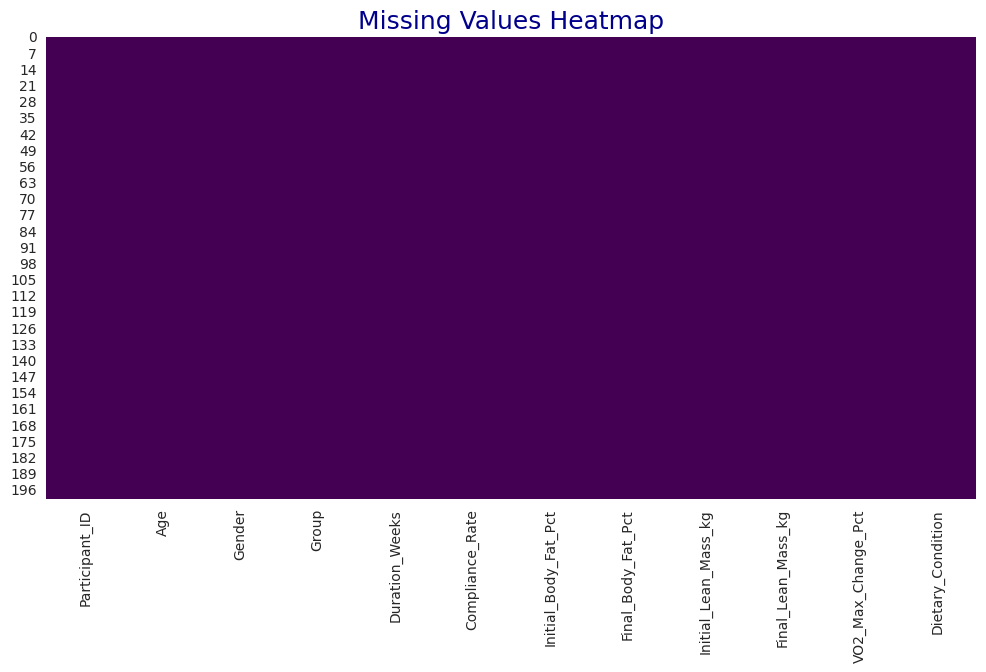

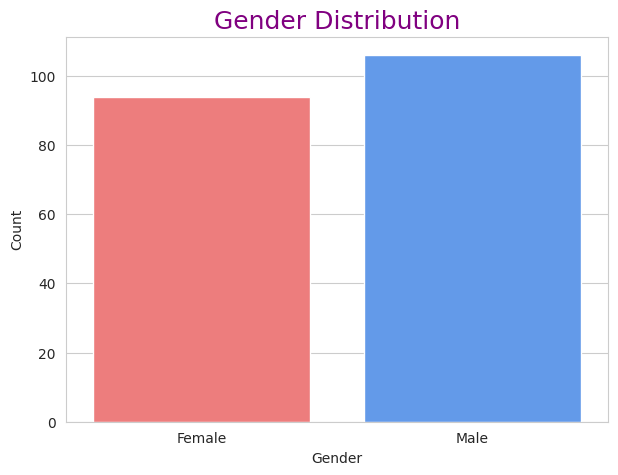

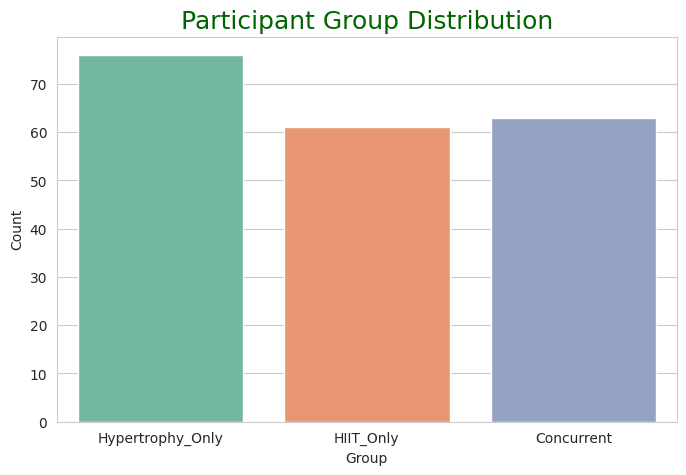

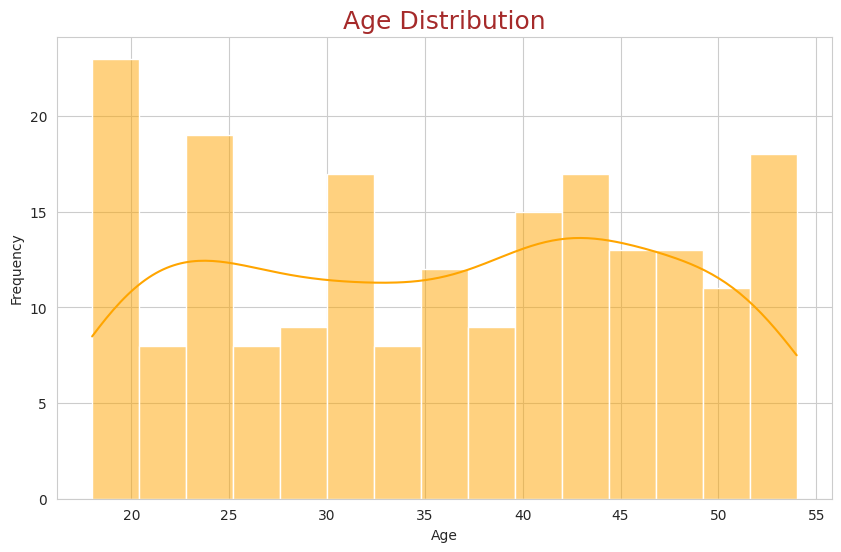

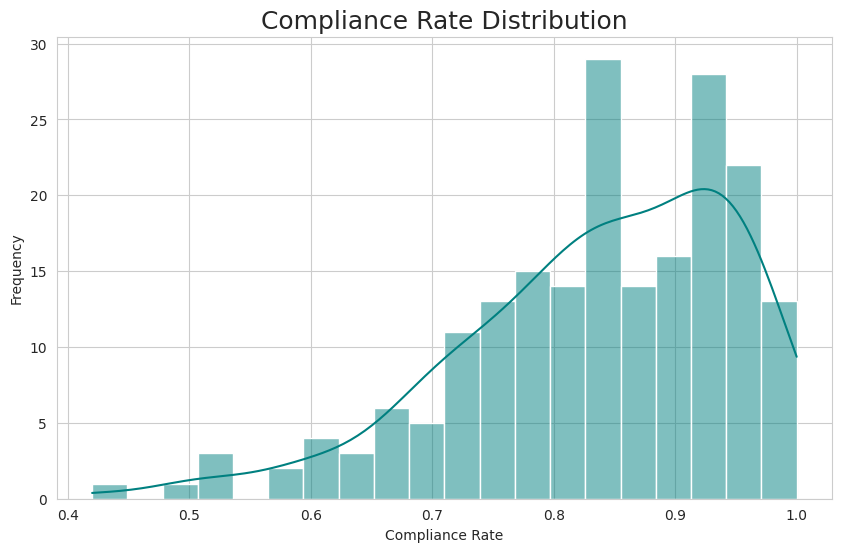

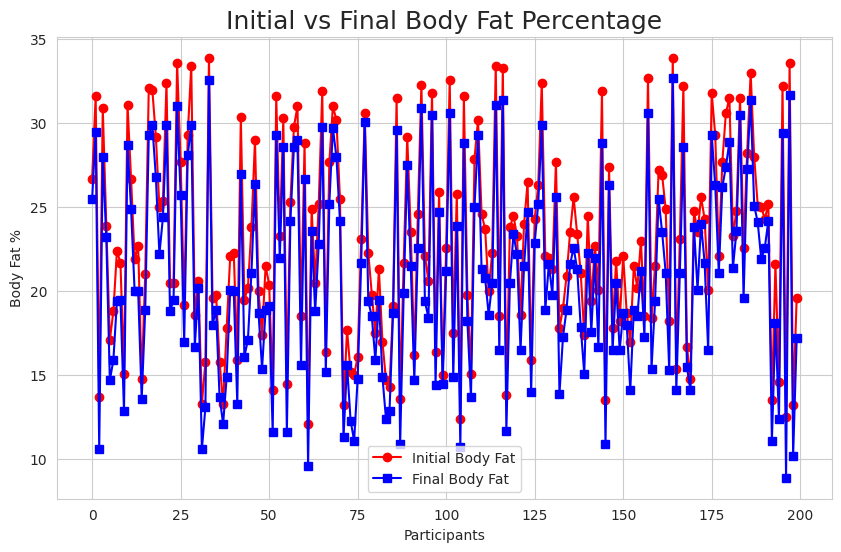

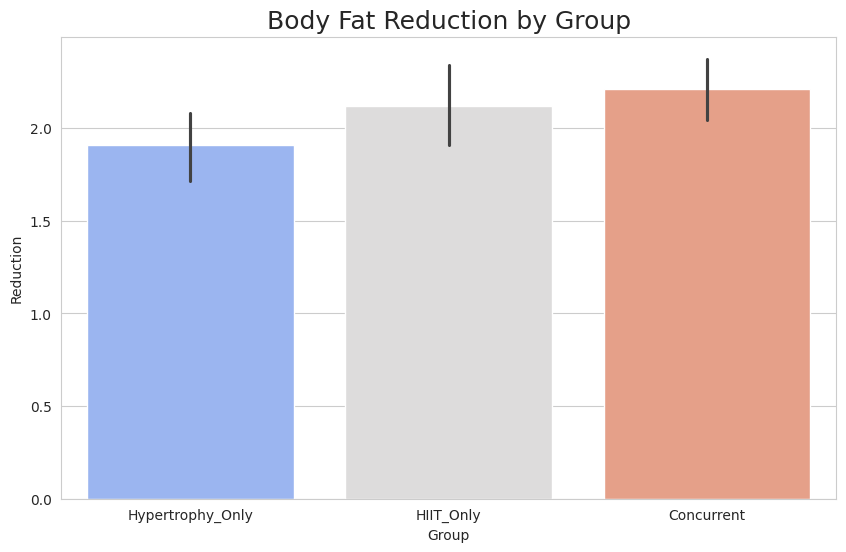

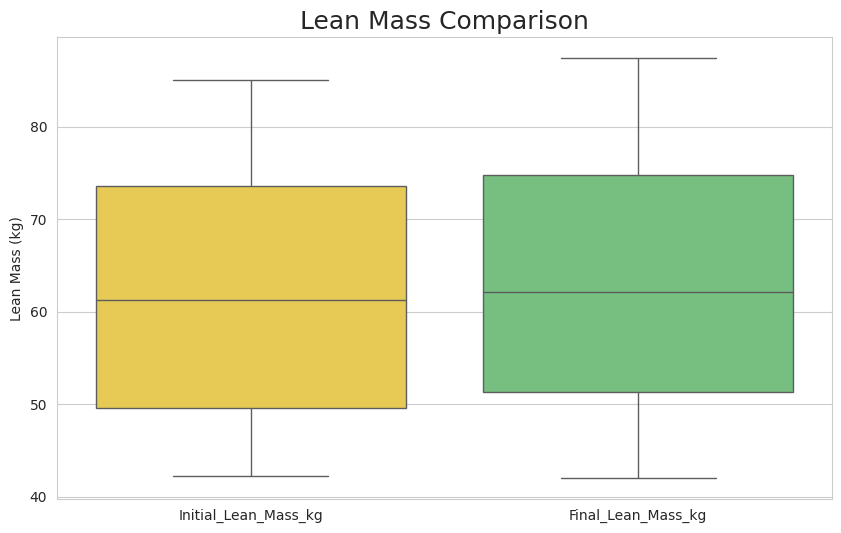

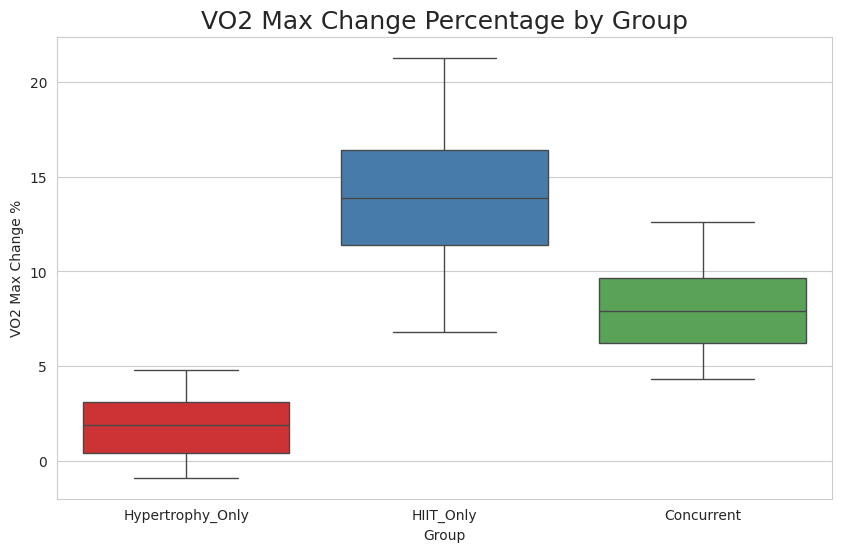

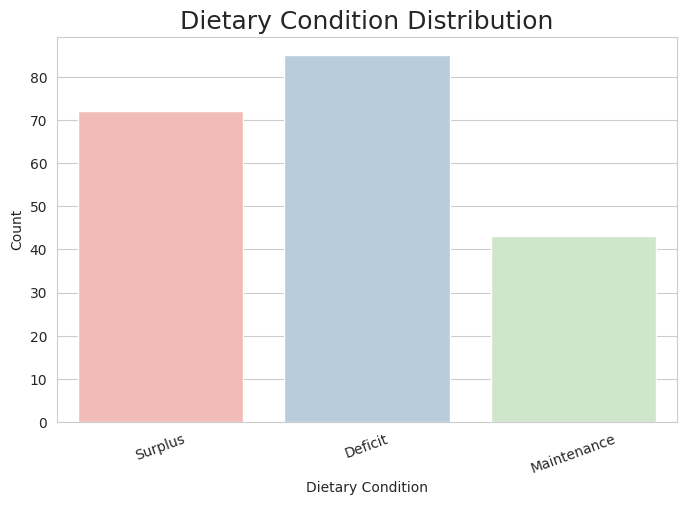

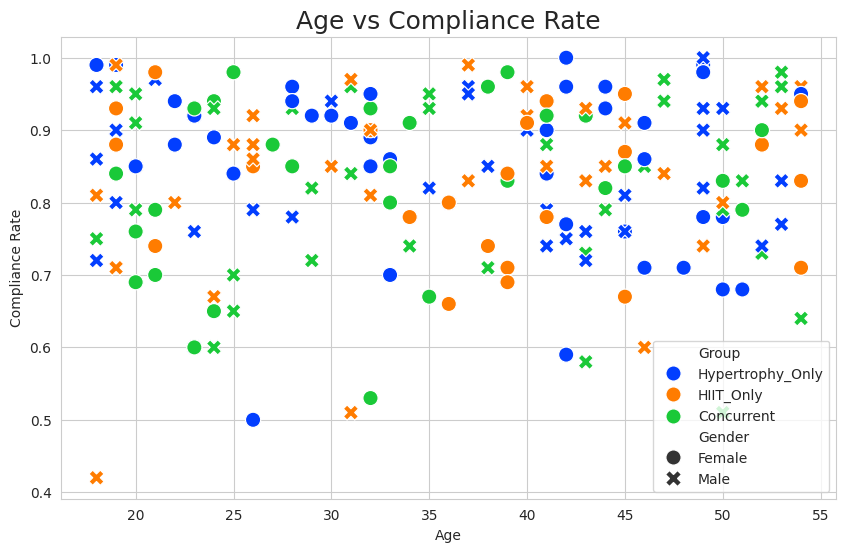

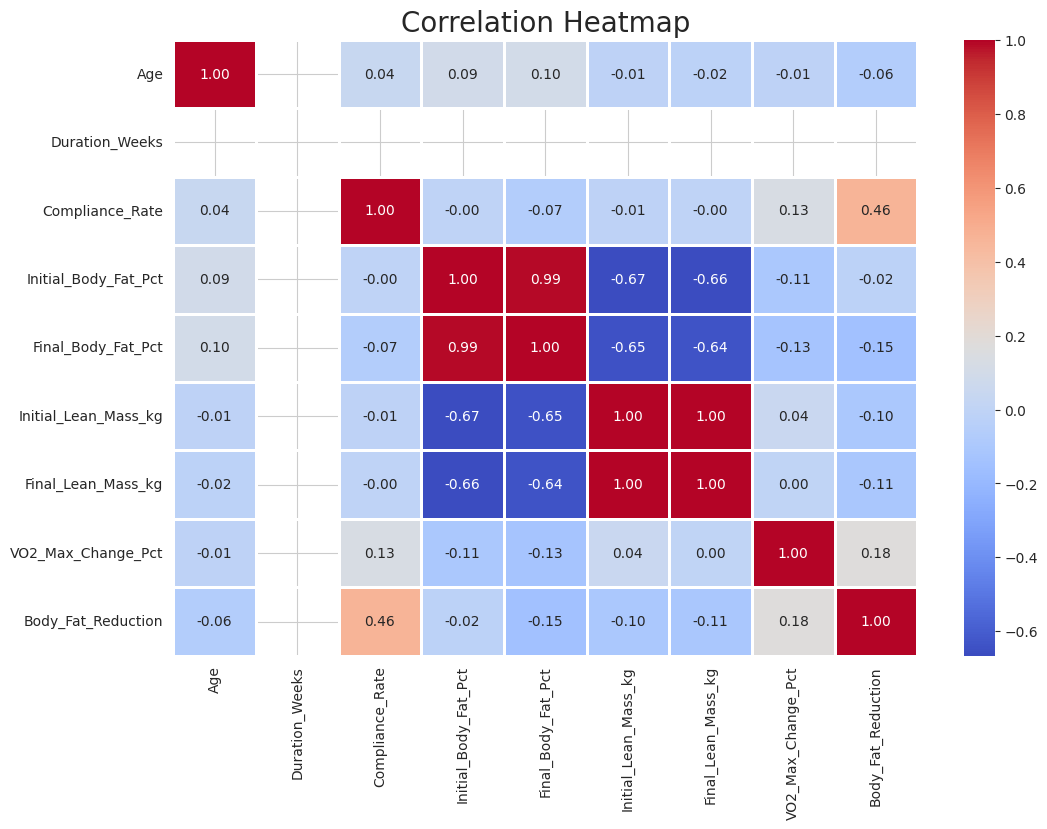

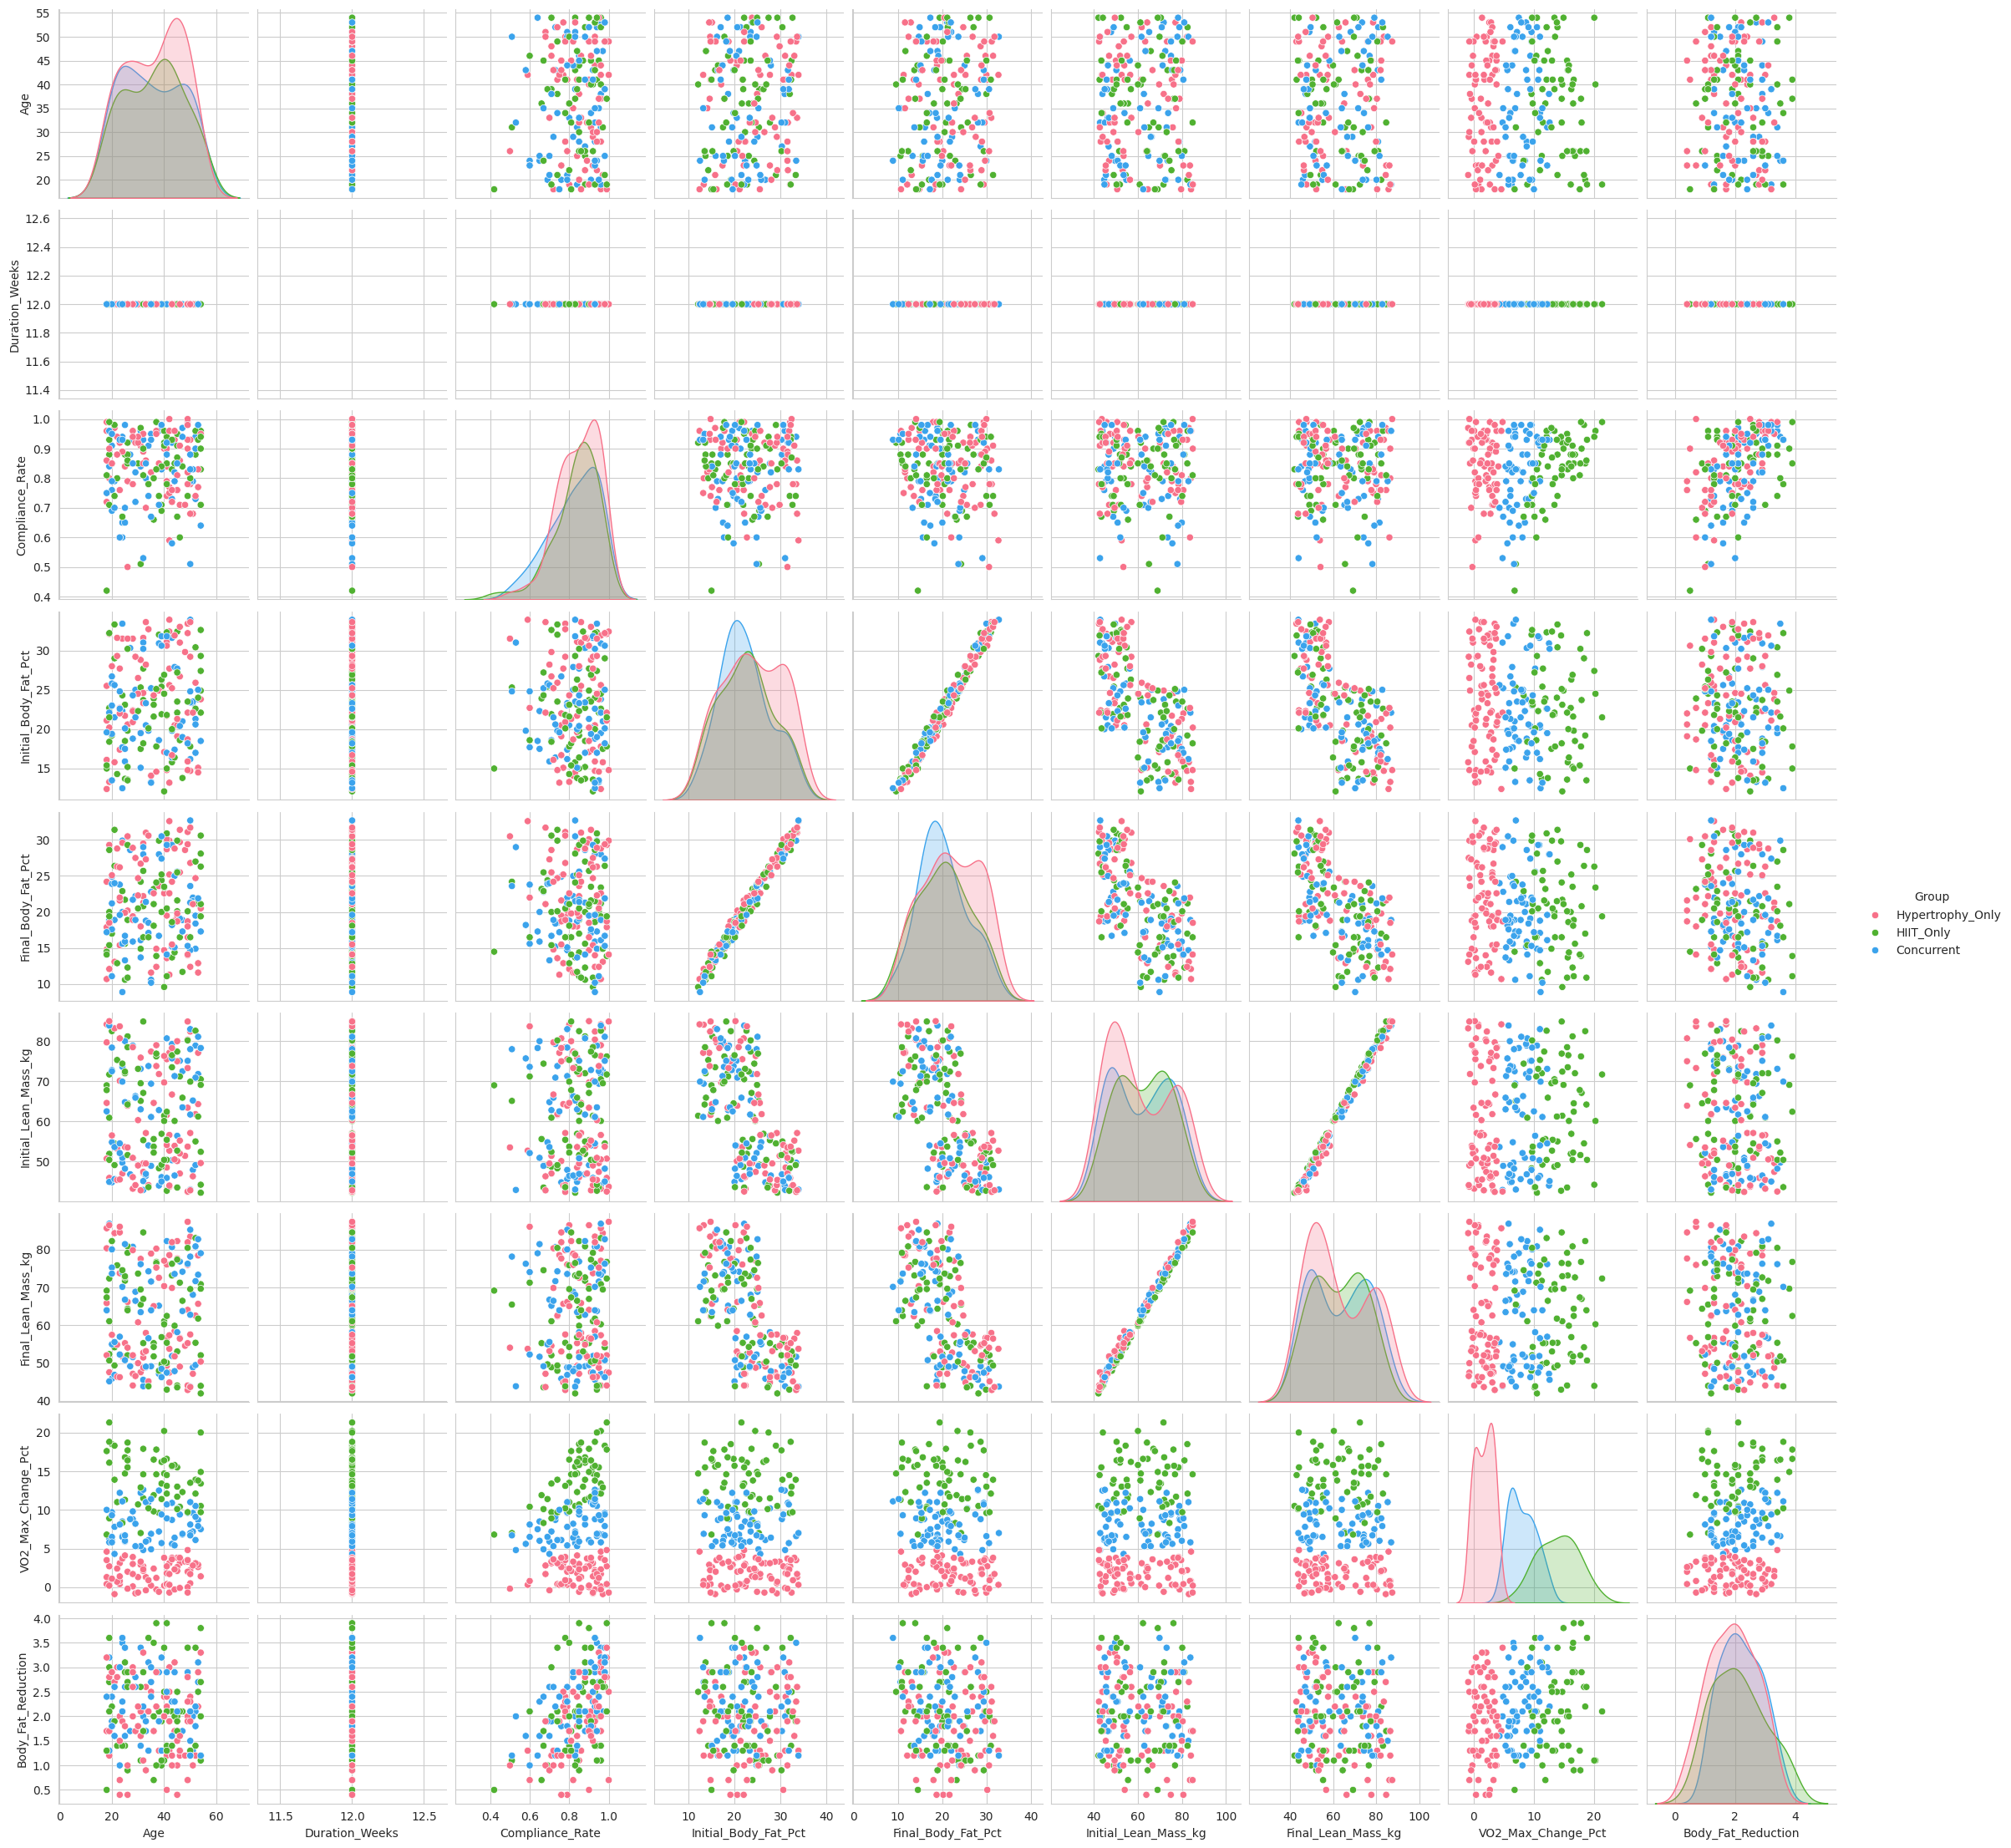

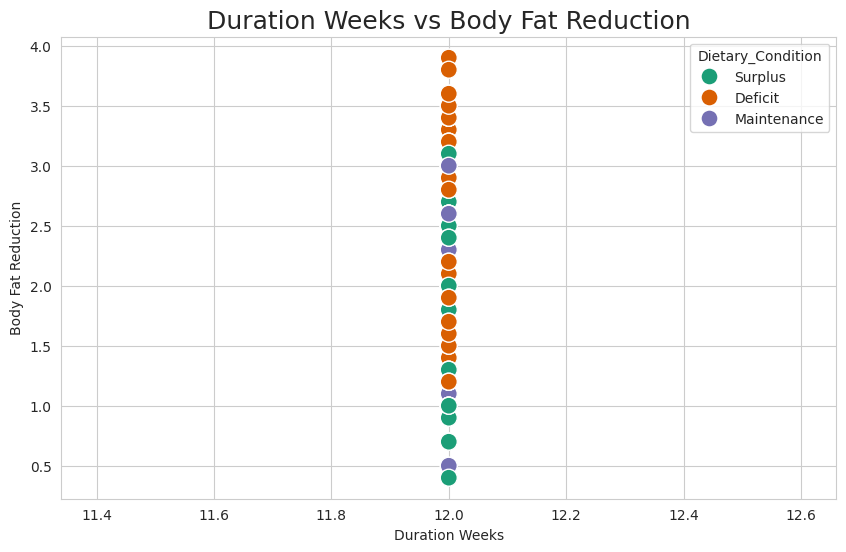

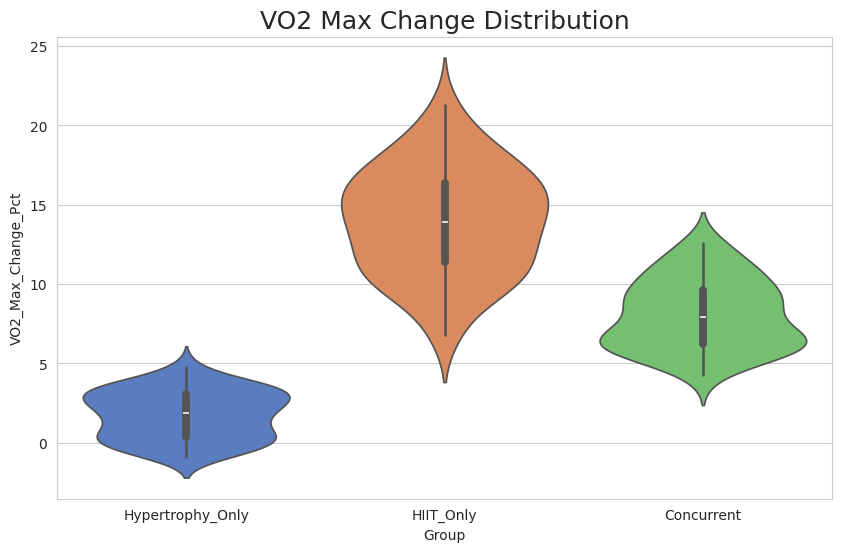

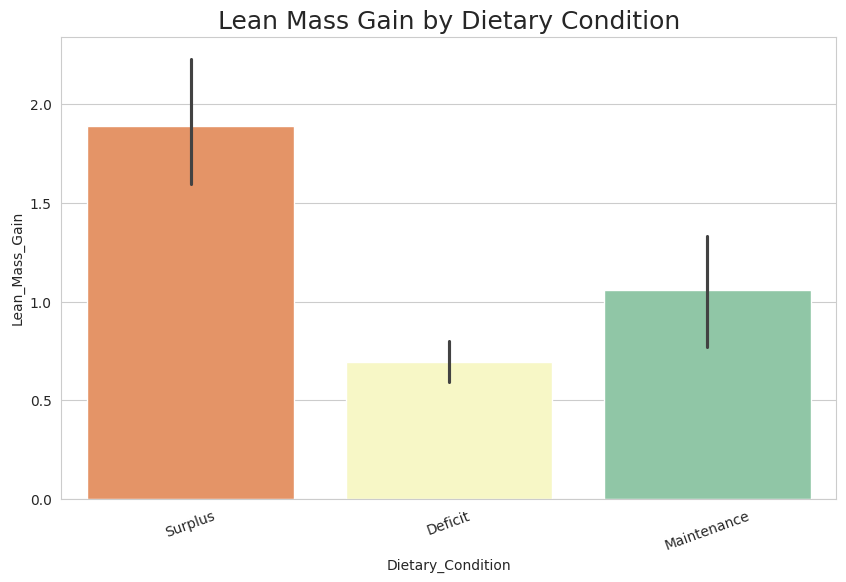

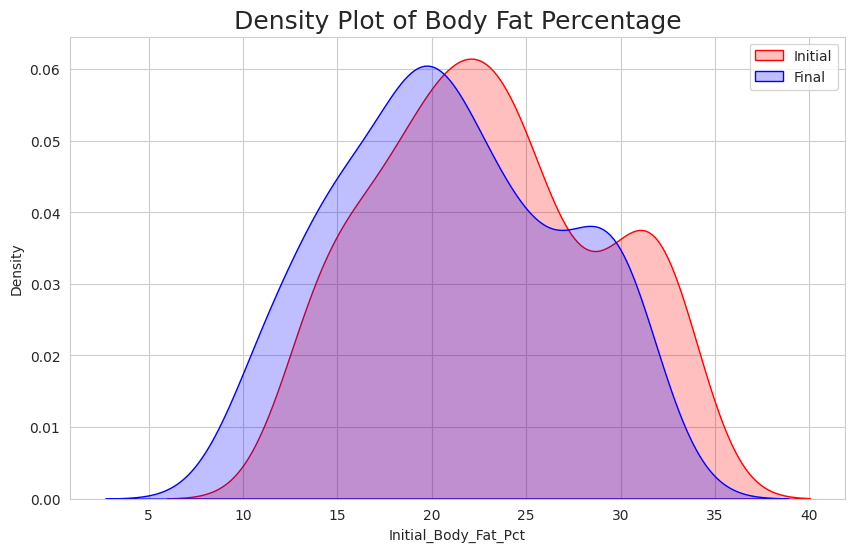

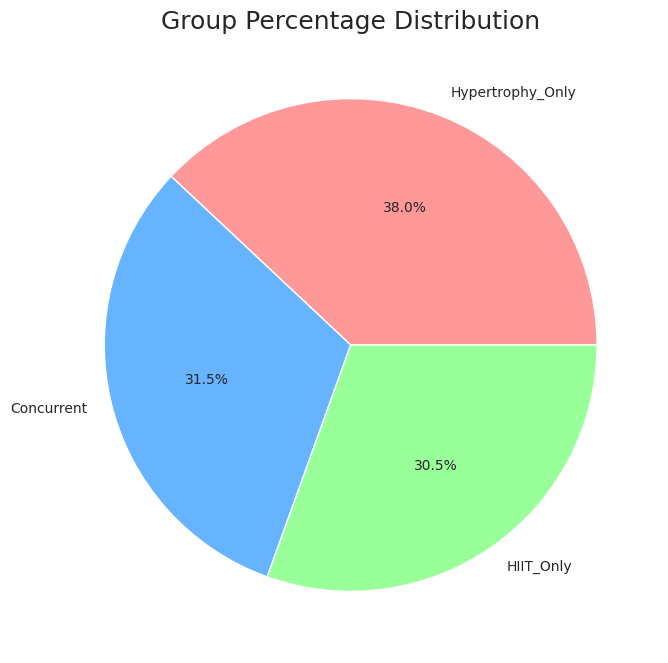

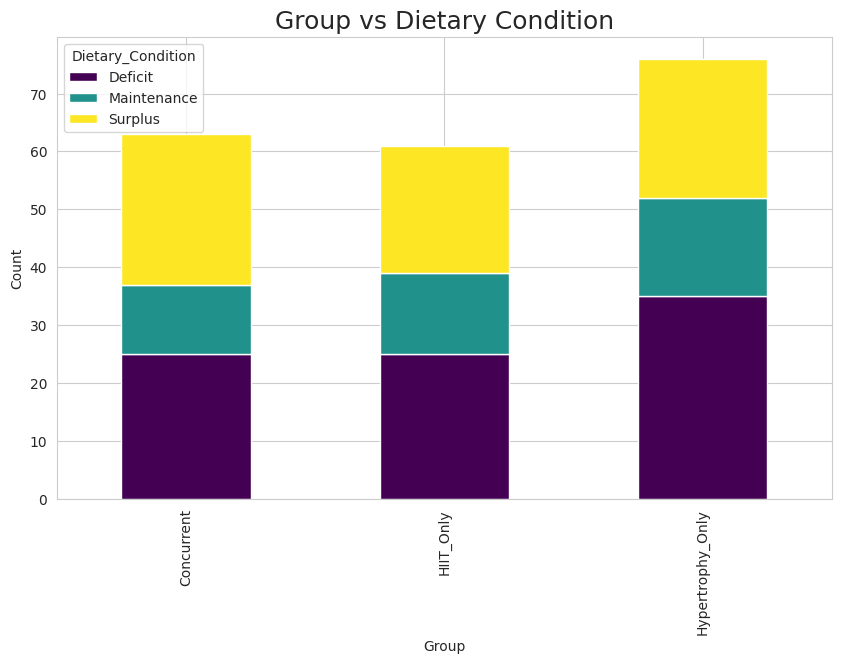


Visualization Completed Successfully!
Total Rows : 200
Total Columns : 14


In [14]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10,6)

# ============================================
# 1. MISSING VALUES VISUALIZATION
# ============================================

plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Values Heatmap", fontsize=18, color='darkblue')
plt.show()

# ============================================
# 2. GENDER DISTRIBUTION
# ============================================

plt.figure(figsize=(7,5))
sns.countplot(
    x='Gender',
    data=df,
    palette=['#FF6B6B', '#4D96FF']
)

plt.title("Gender Distribution", fontsize=18, color='purple')
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

# ============================================
# 3. GROUP DISTRIBUTION
# ============================================

plt.figure(figsize=(8,5))
sns.countplot(
    x='Group',
    data=df,
    palette='Set2'
)

plt.title("Participant Group Distribution", fontsize=18, color='darkgreen')
plt.xlabel("Group")
plt.ylabel("Count")
plt.show()

# ============================================
# 4. AGE DISTRIBUTION
# ============================================

plt.figure(figsize=(10,6))
sns.histplot(
    df['Age'],
    bins=15,
    kde=True,
    color='orange'
)

plt.title("Age Distribution", fontsize=18, color='brown')
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

# ============================================
# 5. COMPLIANCE RATE DISTRIBUTION
# ============================================

plt.figure(figsize=(10,6))
sns.histplot(
    df['Compliance_Rate'],
    bins=20,
    kde=True,
    color='teal'
)

plt.title("Compliance Rate Distribution", fontsize=18)
plt.xlabel("Compliance Rate")
plt.ylabel("Frequency")
plt.show()

# ============================================
# 6. INITIAL VS FINAL BODY FAT %
# ============================================

plt.figure(figsize=(10,6))

plt.plot(
    df['Initial_Body_Fat_Pct'],
    label='Initial Body Fat',
    color='red',
    marker='o'
)

plt.plot(
    df['Final_Body_Fat_Pct'],
    label='Final Body Fat',
    color='blue',
    marker='s'
)

plt.title("Initial vs Final Body Fat Percentage", fontsize=18)
plt.xlabel("Participants")
plt.ylabel("Body Fat %")
plt.legend()
plt.show()

# ============================================
# 7. BODY FAT REDUCTION
# ============================================

df['Body_Fat_Reduction'] = (
    df['Initial_Body_Fat_Pct'] - df['Final_Body_Fat_Pct']
)

plt.figure(figsize=(10,6))

sns.barplot(
    x='Group',
    y='Body_Fat_Reduction',
    data=df,
    palette='coolwarm'
)

plt.title("Body Fat Reduction by Group", fontsize=18)
plt.xlabel("Group")
plt.ylabel("Reduction")
plt.show()

# ============================================
# 8. LEAN MASS COMPARISON
# ============================================

plt.figure(figsize=(10,6))

sns.boxplot(
    data=df[['Initial_Lean_Mass_kg', 'Final_Lean_Mass_kg']],
    palette=['#FFD93D', '#6BCB77']
)

plt.title("Lean Mass Comparison", fontsize=18)
plt.ylabel("Lean Mass (kg)")
plt.show()

# ============================================
# 9. VO2 MAX CHANGE BY GROUP
# ============================================

plt.figure(figsize=(10,6))

sns.boxplot(
    x='Group',
    y='VO2_Max_Change_Pct',
    data=df,
    palette='Set1'
)

plt.title("VO2 Max Change Percentage by Group", fontsize=18)
plt.xlabel("Group")
plt.ylabel("VO2 Max Change %")
plt.show()

# ============================================
# 10. DIETARY CONDITION DISTRIBUTION
# ============================================

plt.figure(figsize=(8,5))

sns.countplot(
    x='Dietary_Condition',
    data=df,
    palette='Pastel1'
)

plt.title("Dietary Condition Distribution", fontsize=18)
plt.xlabel("Dietary Condition")
plt.ylabel("Count")
plt.xticks(rotation=20)
plt.show()

# ============================================
# 11. AGE VS COMPLIANCE RATE
# ============================================

plt.figure(figsize=(10,6))

sns.scatterplot(
    x='Age',
    y='Compliance_Rate',
    hue='Group',
    style='Gender',
    palette='bright',
    s=120,
    data=df
)

plt.title("Age vs Compliance Rate", fontsize=18)
plt.xlabel("Age")
plt.ylabel("Compliance Rate")
plt.show()

# ============================================
# 12. BODY FAT CORRELATION HEATMAP
# ============================================

numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(12,8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=1
)

plt.title("Correlation Heatmap", fontsize=20)
plt.show()

# ============================================
# 13. PAIRPLOT VISUALIZATION
# ============================================

sns.pairplot(
    df,
    hue='Group',
    palette='husl'
)

plt.show()

# ============================================
# 14. DURATION WEEKS VS BODY FAT REDUCTION
# ============================================

plt.figure(figsize=(10,6))

sns.scatterplot(
    x='Duration_Weeks',
    y='Body_Fat_Reduction',
    hue='Dietary_Condition',
    palette='Dark2',
    s=150,
    data=df
)

plt.title("Duration Weeks vs Body Fat Reduction", fontsize=18)
plt.xlabel("Duration Weeks")
plt.ylabel("Body Fat Reduction")
plt.show()

# ============================================
# 15. VIOLIN PLOT OF VO2 MAX CHANGE
# ============================================

plt.figure(figsize=(10,6))

sns.violinplot(
    x='Group',
    y='VO2_Max_Change_Pct',
    data=df,
    palette='muted'
)

plt.title("VO2 Max Change Distribution", fontsize=18)
plt.show()

# ============================================
# 16. LEAN MASS GAIN
# ============================================

df['Lean_Mass_Gain'] = (
    df['Final_Lean_Mass_kg'] - df['Initial_Lean_Mass_kg']
)

plt.figure(figsize=(10,6))

sns.barplot(
    x='Dietary_Condition',
    y='Lean_Mass_Gain',
    palette='Spectral',
    data=df
)

plt.title("Lean Mass Gain by Dietary Condition", fontsize=18)
plt.xticks(rotation=20)
plt.show()

# ============================================
# 17. KDE PLOT
# ============================================

plt.figure(figsize=(10,6))

sns.kdeplot(
    df['Initial_Body_Fat_Pct'],
    fill=True,
    color='red',
    label='Initial'
)

sns.kdeplot(
    df['Final_Body_Fat_Pct'],
    fill=True,
    color='blue',
    label='Final'
)

plt.title("Density Plot of Body Fat Percentage", fontsize=18)
plt.legend()
plt.show()

# ============================================
# 18. PIE CHART OF GROUPS
# ============================================

group_counts = df['Group'].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    group_counts,
    labels=group_counts.index,
    autopct='%1.1f%%',
    colors=['#ff9999','#66b3ff','#99ff99','#ffcc99']
)

plt.title("Group Percentage Distribution", fontsize=18)
plt.show()

# ============================================
# 19. STACKED BAR CHART
# ============================================

cross_tab = pd.crosstab(df['Group'], df['Dietary_Condition'])

cross_tab.plot(
    kind='bar',
    stacked=True,
    figsize=(10,6),
    colormap='viridis'
)

plt.title("Group vs Dietary Condition", fontsize=18)
plt.xlabel("Group")
plt.ylabel("Count")
plt.show()

# ============================================
# 20. FINAL SUMMARY
# ============================================

print("\nVisualization Completed Successfully!")
print("Total Rows :", df.shape[0])
print("Total Columns :", df.shape[1])

## Feature engineering

In [15]:
# Train Test Split
from sklearn.model_selection import train_test_split

# Preprocessing
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)



Target Value Counts
Target
1    108
0     92
Name: count, dtype: int64

Categorical Columns
Index(['Gender', 'Group', 'Dietary_Condition'], dtype='object')

Numerical Columns
Index(['Age', 'Duration_Weeks', 'Compliance_Rate', 'Initial_Body_Fat_Pct',
       'Initial_Lean_Mass_kg', 'Final_Lean_Mass_kg', 'VO2_Max_Change_Pct'],
      dtype='object')

Training Shape
(160, 10)

Testing Shape
(40, 10)


MODEL : Logistic Regression

Accuracy : 0.6250

Classification Report
              precision    recall  f1-score   support

           0       0.57      0.72      0.63        18
           1       0.71      0.55      0.62        22

    accuracy                           0.62        40
   macro avg       0.64      0.63      0.62        40
weighted avg       0.64      0.62      0.62        40



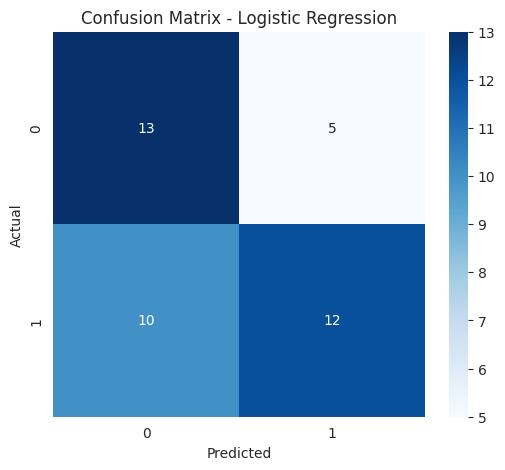

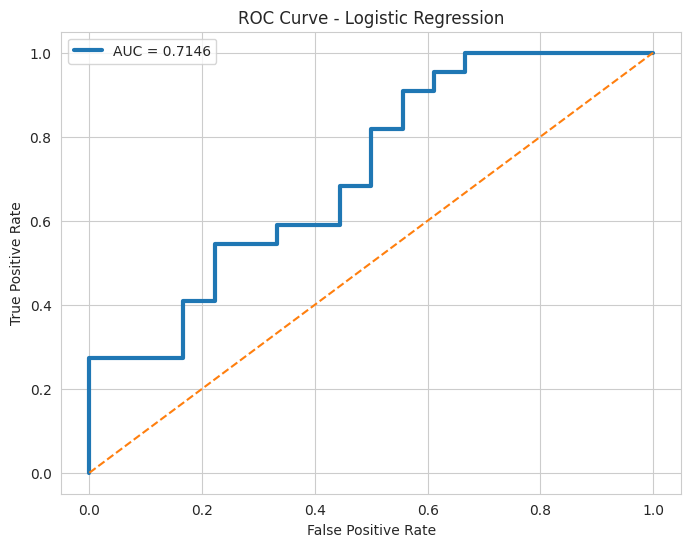



MODEL : Decision Tree

Accuracy : 0.6000

Classification Report
              precision    recall  f1-score   support

           0       0.54      0.72      0.62        18
           1       0.69      0.50      0.58        22

    accuracy                           0.60        40
   macro avg       0.61      0.61      0.60        40
weighted avg       0.62      0.60      0.60        40



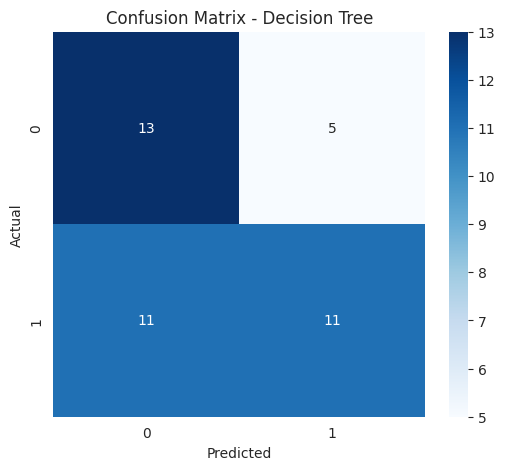

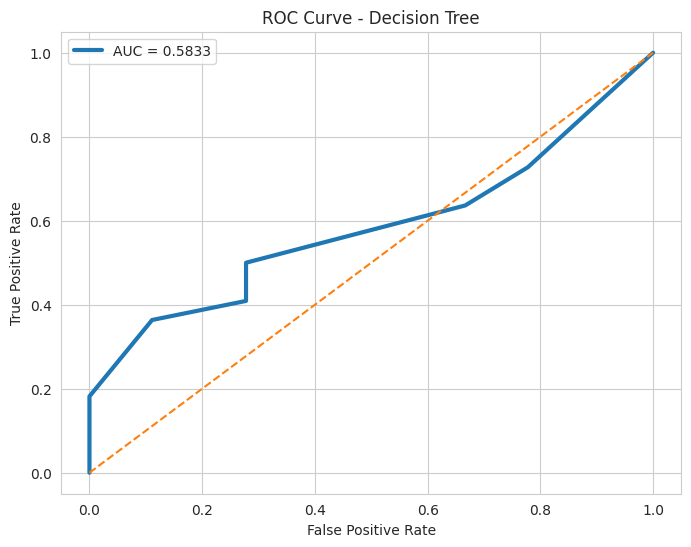



MODEL : Random Forest

Accuracy : 0.6000

Classification Report
              precision    recall  f1-score   support

           0       0.54      0.72      0.62        18
           1       0.69      0.50      0.58        22

    accuracy                           0.60        40
   macro avg       0.61      0.61      0.60        40
weighted avg       0.62      0.60      0.60        40



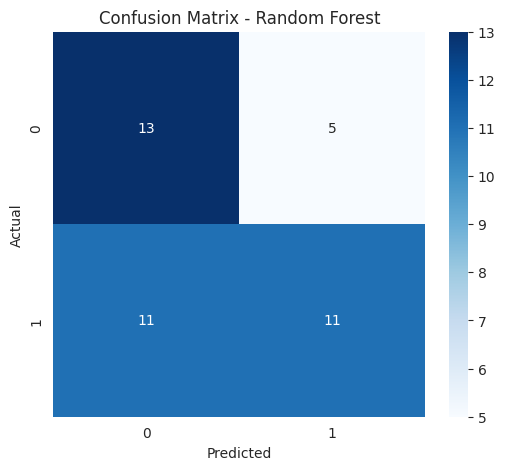

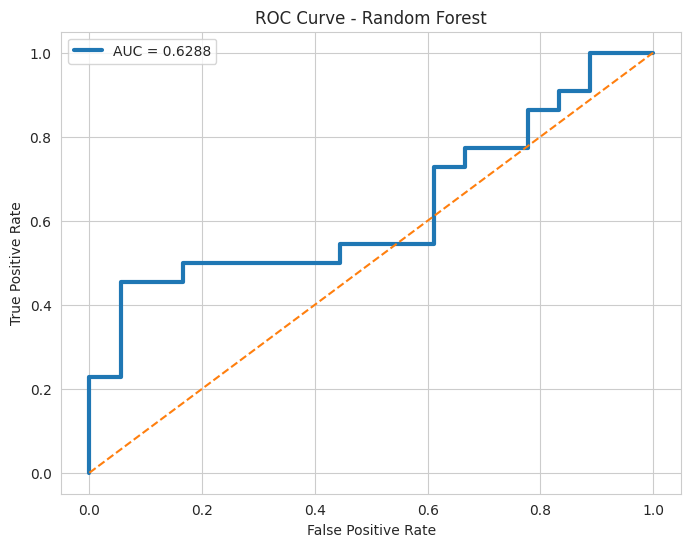



MODEL : KNN

Accuracy : 0.6750

Classification Report
              precision    recall  f1-score   support

           0       0.63      0.67      0.65        18
           1       0.71      0.68      0.70        22

    accuracy                           0.68        40
   macro avg       0.67      0.67      0.67        40
weighted avg       0.68      0.68      0.68        40



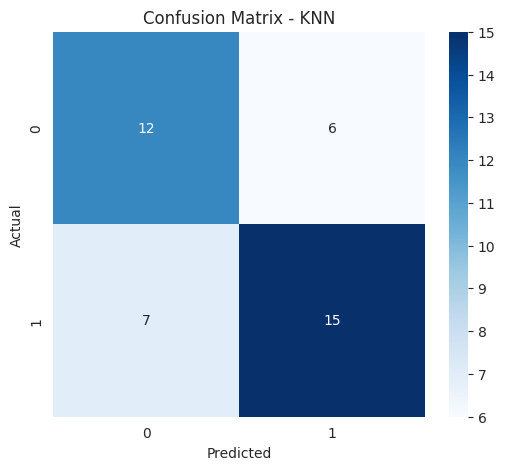

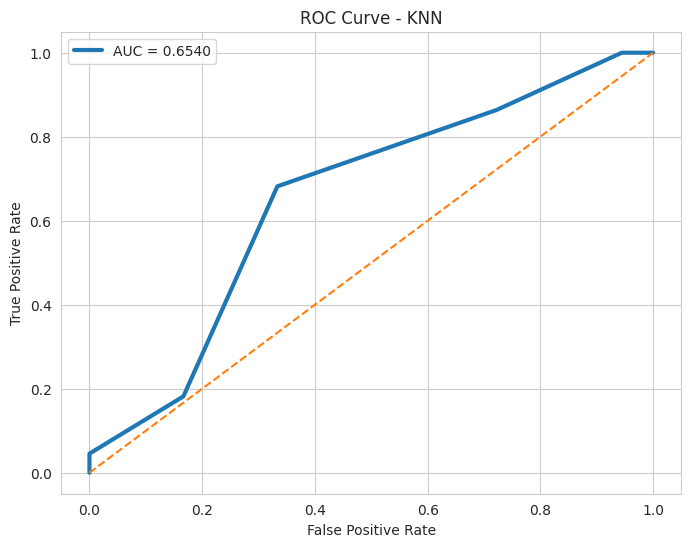



MODEL : SVM

Accuracy : 0.6500

Classification Report
              precision    recall  f1-score   support

           0       0.61      0.61      0.61        18
           1       0.68      0.68      0.68        22

    accuracy                           0.65        40
   macro avg       0.65      0.65      0.65        40
weighted avg       0.65      0.65      0.65        40



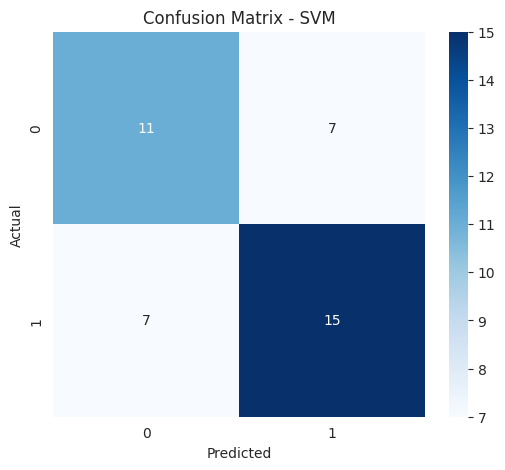

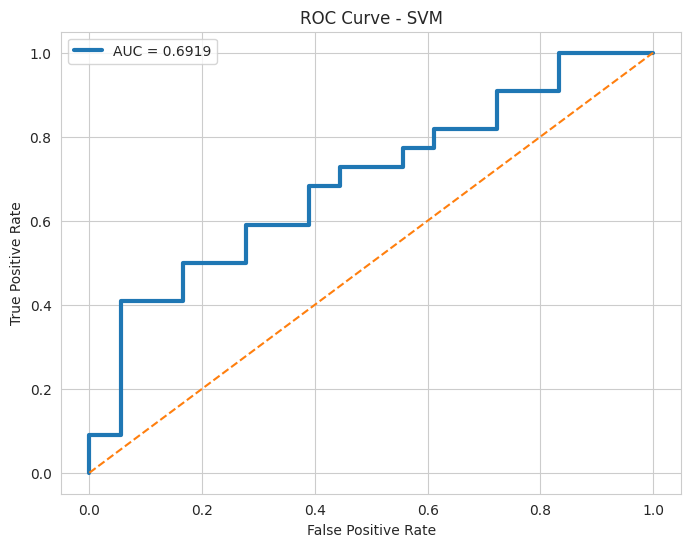



MODEL : Naive Bayes

Accuracy : 0.5500

Classification Report
              precision    recall  f1-score   support

           0       0.50      0.61      0.55        18
           1       0.61      0.50      0.55        22

    accuracy                           0.55        40
   macro avg       0.56      0.56      0.55        40
weighted avg       0.56      0.55      0.55        40



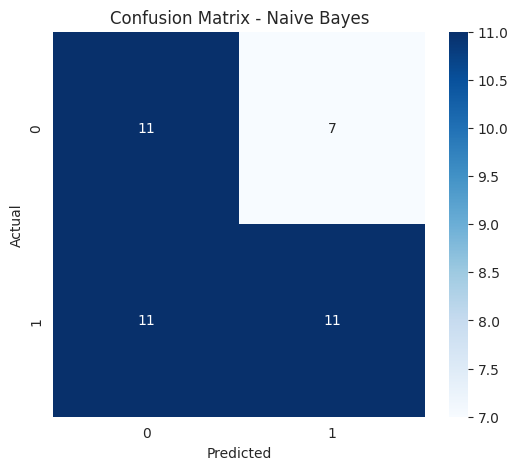

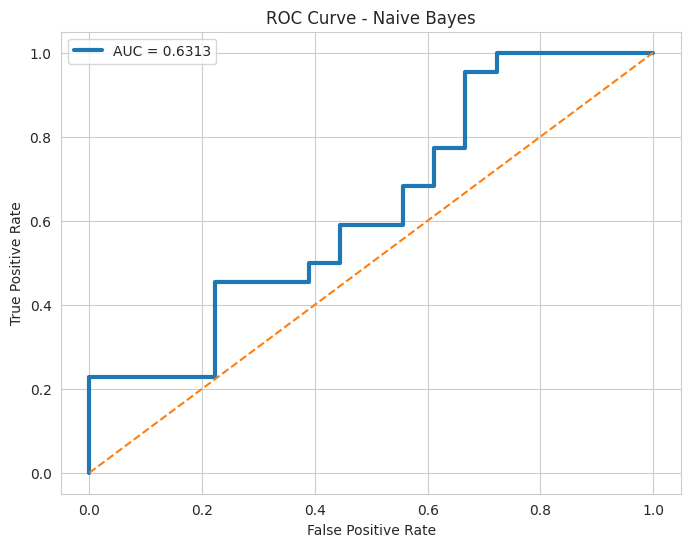



FINAL MODEL COMPARISON
                 Model  Accuracy   ROC_AUC
0  Logistic Regression     0.625  0.714646
1        Decision Tree     0.600  0.583333
2        Random Forest     0.600  0.628788
3                  KNN     0.675  0.654040
4                  SVM     0.650  0.691919
5          Naive Bayes     0.550  0.631313


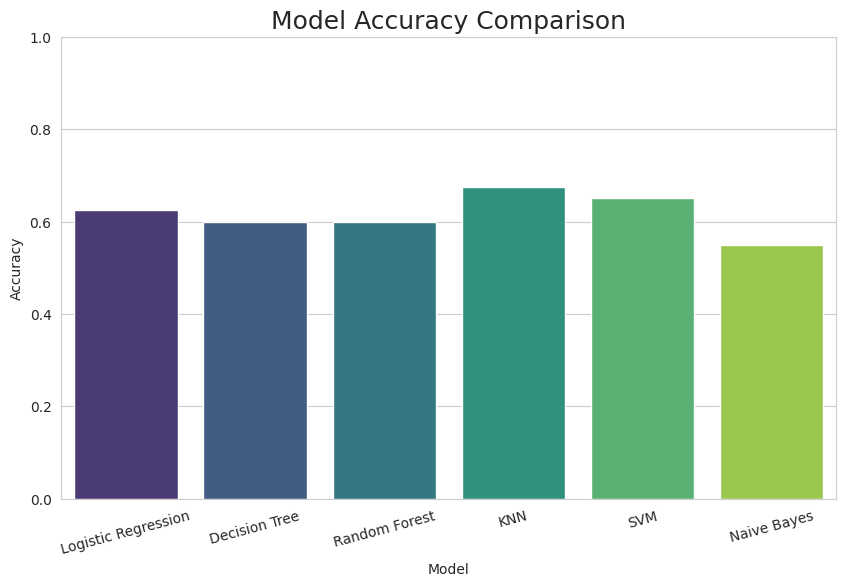

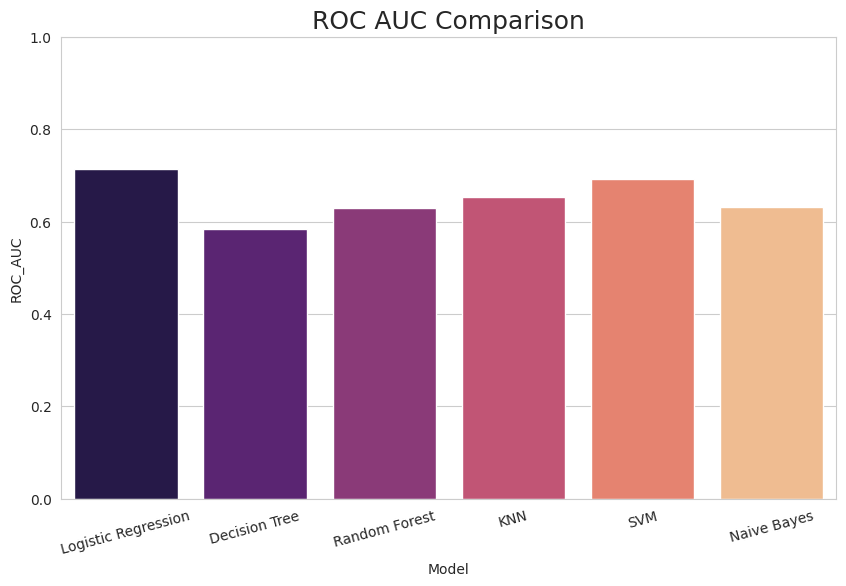



BEST MODEL
Best Model : Logistic Regression
Accuracy   : 0.6250
ROC AUC    : 0.7146

Top Important Features
                          Feature  Importance
2                 Compliance_Rate    0.207469
6              VO2_Max_Change_Pct    0.143869
5              Final_Lean_Mass_kg    0.123291
4            Initial_Lean_Mass_kg    0.121585
3            Initial_Body_Fat_Pct    0.113706
0                             Age    0.099171
14      Dietary_Condition_Surplus    0.036592
12      Dietary_Condition_Deficit    0.035805
13  Dietary_Condition_Maintenance    0.032211
11         Group_Hypertrophy_Only    0.024430
9                Group_Concurrent    0.021887
10                Group_HIIT_Only    0.020255
7                   Gender_Female    0.010427
8                     Gender_Male    0.009302
1                  Duration_Weeks    0.000000


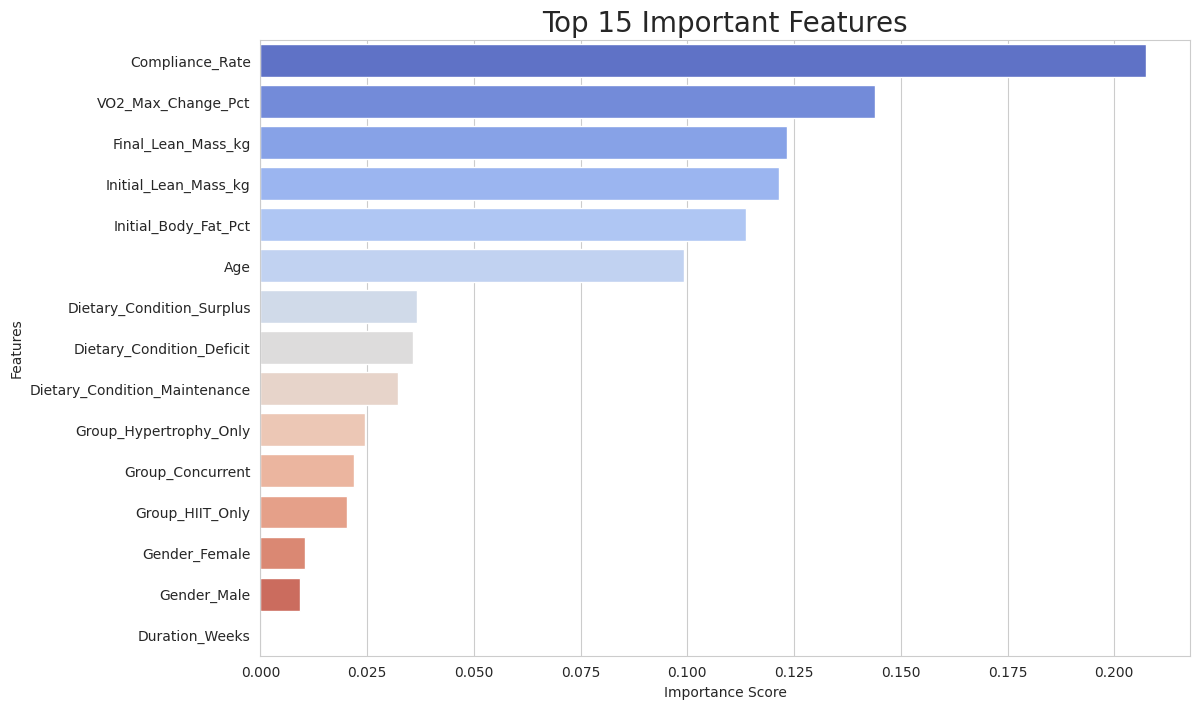

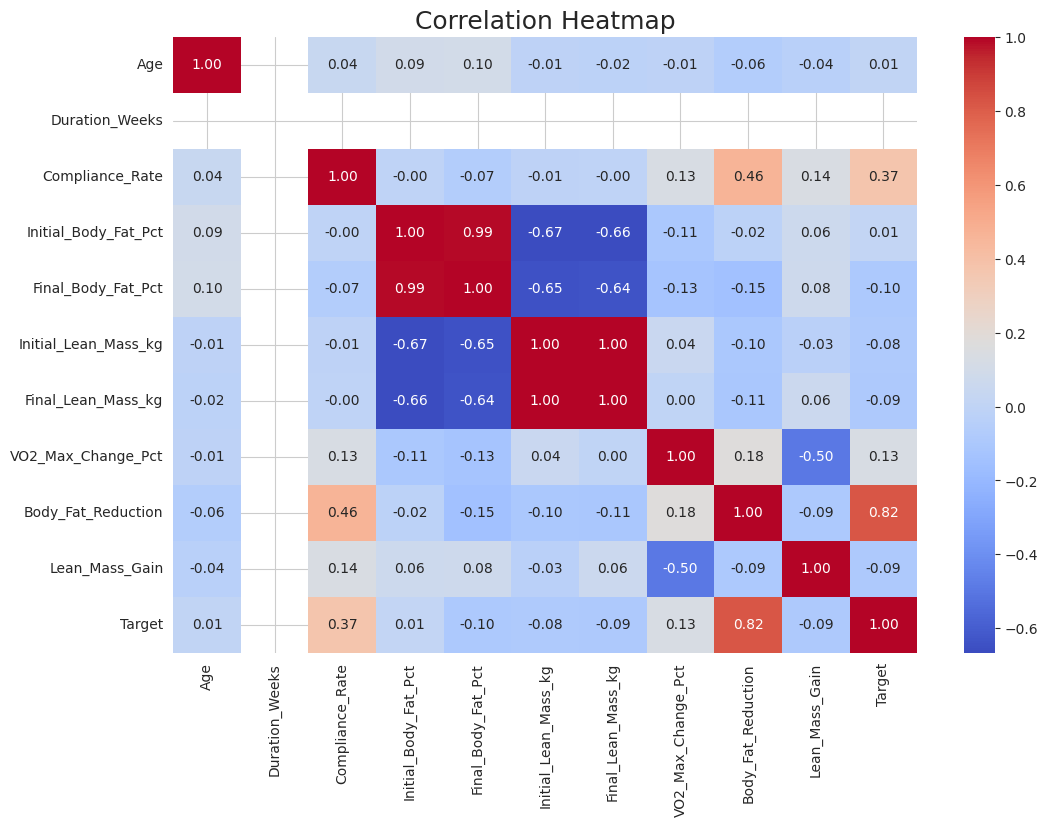



MACHINE LEARNING PIPELINE COMPLETED SUCCESSFULLY


In [16]:
# Body Fat Reduction
df['Body_Fat_Reduction'] = (
    df['Initial_Body_Fat_Pct'] -
    df['Final_Body_Fat_Pct']
)

# Lean Mass Gain
df['Lean_Mass_Gain'] = (
    df['Final_Lean_Mass_kg'] -
    df['Initial_Lean_Mass_kg']
)

# ==========================================================
# CREATE TARGET COLUMN
# ==========================================================
# Higher Body Fat Reduction = 1
# Lower Body Fat Reduction = 0
# ==========================================================

threshold = df['Body_Fat_Reduction'].median()

df['Target'] = np.where(
    df['Body_Fat_Reduction'] >= threshold,
    1,
    0
)

# ==========================================================
# CHECK TARGET DISTRIBUTION
# ==========================================================

print("\nTarget Value Counts")
print(df['Target'].value_counts())

# ==========================================================
# REMOVE DATA LEAKAGE COLUMNS
# ==========================================================

X = df.drop(columns=[
    'Participant_ID',
    'Target',
    'Final_Body_Fat_Pct',
    'Body_Fat_Reduction',
    'Lean_Mass_Gain'
])

y = df['Target']

# ==========================================================
# IDENTIFY COLUMN TYPES
# ==========================================================

categorical_columns = X.select_dtypes(include=['object']).columns

numerical_columns = X.select_dtypes(exclude=['object']).columns

print("\nCategorical Columns")
print(categorical_columns)

print("\nNumerical Columns")
print(numerical_columns)

# ==========================================================
# TRAIN TEST SPLIT
# ==========================================================
# IMPORTANT:
# Split BEFORE preprocessing
# Prevents data leakage
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining Shape")
print(X_train.shape)

print("\nTesting Shape")
print(X_test.shape)

# ==========================================================
# PREPROCESSING PIPELINE
# ==========================================================

# Numerical Pipeline
numeric_transformer = Pipeline(steps=[

    ('imputer', SimpleImputer(strategy='median')),

    ('scaler', StandardScaler())

])

# Categorical Pipeline
categorical_transformer = Pipeline(steps=[

    ('imputer', SimpleImputer(strategy='most_frequent')),

    ('encoder', OneHotEncoder(handle_unknown='ignore'))

])

# Combine Preprocessing
preprocessor = ColumnTransformer(

    transformers=[

        ('num', numeric_transformer, numerical_columns),

        ('cat', categorical_transformer, categorical_columns)

    ]

)

# ==========================================================
# DEFINE MACHINE LEARNING MODELS
# ==========================================================

models = {

    "Logistic Regression": LogisticRegression(
        max_iter=1000
    ),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=5,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=8,
        random_state=42
    ),

    "KNN": KNeighborsClassifier(
        n_neighbors=5
    ),

    "SVM": SVC(
        probability=True,
        kernel='rbf',
        random_state=42
    ),

    "Naive Bayes": GaussianNB()

}

# ==========================================================
# STORE RESULTS
# ==========================================================

results = []

# ==========================================================
# TRAIN AND EVALUATE ALL MODELS
# ==========================================================

for model_name, model in models.items():

    print("\n")
    print("="*70)
    print(f"MODEL : {model_name}")
    print("="*70)

    # ======================================================
    # CREATE PIPELINE
    # ======================================================

    pipeline = Pipeline(steps=[

        ('preprocessor', preprocessor),

        ('classifier', model)

    ])

    # ======================================================
    # TRAIN MODEL
    # ======================================================

    pipeline.fit(X_train, y_train)

    # ======================================================
    # PREDICTIONS
    # ======================================================

    y_pred = pipeline.predict(X_test)

    # ======================================================
    # PREDICTION PROBABILITIES
    # ======================================================

    y_prob = pipeline.predict_proba(X_test)[:,1]

    # ======================================================
    # ACCURACY
    # ======================================================

    accuracy = accuracy_score(y_test, y_pred)

    print(f"\nAccuracy : {accuracy:.4f}")

    # ======================================================
    # CLASSIFICATION REPORT
    # ======================================================

    print("\nClassification Report")

    print(classification_report(y_test, y_pred))

    # ======================================================
    # CONFUSION MATRIX
    # ======================================================

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6,5))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues'
    )

    plt.title(f'Confusion Matrix - {model_name}')

    plt.xlabel("Predicted")

    plt.ylabel("Actual")

    plt.show()

    # ======================================================
    # ROC CURVE
    # ======================================================

    fpr, tpr, thresholds = roc_curve(y_test, y_prob)

    roc_auc = roc_auc_score(y_test, y_prob)

    plt.figure(figsize=(8,6))

    plt.plot(
        fpr,
        tpr,
        linewidth=3,
        label=f'AUC = {roc_auc:.4f}'
    )

    plt.plot(
        [0,1],
        [0,1],
        linestyle='--'
    )

    plt.xlabel("False Positive Rate")

    plt.ylabel("True Positive Rate")

    plt.title(f'ROC Curve - {model_name}')

    plt.legend()

    plt.show()

    # ======================================================
    # SAVE RESULTS
    # ======================================================

    results.append({

        'Model': model_name,

        'Accuracy': accuracy,

        'ROC_AUC': roc_auc

    })

# ==========================================================
# FINAL MODEL COMPARISON
# ==========================================================

results_df = pd.DataFrame(results)

print("\n")
print("="*70)
print("FINAL MODEL COMPARISON")
print("="*70)

print(results_df)

# ==========================================================
# ACCURACY COMPARISON PLOT
# ==========================================================

plt.figure(figsize=(10,6))

sns.barplot(
    x='Model',
    y='Accuracy',
    data=results_df,
    palette='viridis'
)

plt.title("Model Accuracy Comparison", fontsize=18)

plt.xticks(rotation=15)

plt.ylim(0,1)

plt.show()

# ==========================================================
# ROC AUC COMPARISON
# ==========================================================

plt.figure(figsize=(10,6))

sns.barplot(
    x='Model',
    y='ROC_AUC',
    data=results_df,
    palette='magma'
)

plt.title("ROC AUC Comparison", fontsize=18)

plt.xticks(rotation=15)

plt.ylim(0,1)

plt.show()

# ==========================================================
# BEST MODEL
# ==========================================================

best_model = results_df.sort_values(
    by='ROC_AUC',
    ascending=False
).iloc[0]

print("\n")
print("="*70)
print("BEST MODEL")
print("="*70)

print(f"Best Model : {best_model['Model']}")

print(f"Accuracy   : {best_model['Accuracy']:.4f}")

print(f"ROC AUC    : {best_model['ROC_AUC']:.4f}")

# ==========================================================
# RANDOM FOREST FEATURE IMPORTANCE
# ==========================================================

rf_pipeline = Pipeline(steps=[

    ('preprocessor', preprocessor),

    ('classifier', RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ))

])

# Train
rf_pipeline.fit(X_train, y_train)

# ==========================================================
# GET FEATURE NAMES
# ==========================================================

encoded_columns = rf_pipeline.named_steps[
    'preprocessor'
].transformers_[1][1].named_steps[
    'encoder'
].get_feature_names_out(categorical_columns)

all_features = list(numerical_columns) + list(encoded_columns)

# ==========================================================
# FEATURE IMPORTANCE VALUES
# ==========================================================

importance_values = rf_pipeline.named_steps[
    'classifier'
].feature_importances_

feature_importance_df = pd.DataFrame({

    'Feature': all_features,

    'Importance': importance_values

})

feature_importance_df = feature_importance_df.sort_values(
    by='Importance',
    ascending=False
)

# ==========================================================
# DISPLAY TOP FEATURES
# ==========================================================

print("\nTop Important Features")

print(feature_importance_df.head(15))

# ==========================================================
# PLOT FEATURE IMPORTANCE
# ==========================================================

plt.figure(figsize=(12,8))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance_df.head(15),
    palette='coolwarm'
)

plt.title("Top 15 Important Features", fontsize=20)

plt.xlabel("Importance Score")

plt.ylabel("Features")

plt.show()

# ==========================================================
# CORRELATION HEATMAP
# ==========================================================

plt.figure(figsize=(12,8))

sns.heatmap(

    df.select_dtypes(include=np.number).corr(),

    annot=True,

    cmap='coolwarm',

    fmt='.2f'

)

plt.title("Correlation Heatmap", fontsize=18)

plt.show()

# ==========================================================
# END
# ==========================================================

print("\n")
print("="*70)
print("MACHINE LEARNING PIPELINE COMPLETED SUCCESSFULLY")
print("="*70)

## Thank you...pls upovte!!!!!!!!!!!!!!!